# Kaggle Playground Series S6E4: Predicting Irrigation Need

**Competition:** [Kaggle Playground Series Season 6, Episode 4](https://www.kaggle.com/competitions/playground-series-s6e4)  
**Task:** Multiclass classification — predict irrigation need (`Low`, `Medium`, or `High`) from agricultural and environmental features  
**Evaluation metric:** Balanced Accuracy  
**Author:** Jessica Middleton  



## Overview

This notebook benchmarks five classification models in sequence, starting from a simple Decision Tree baseline and progressing through ensemble and gradient boosting methods. Both **validation accuracy** and **balanced accuracy** are reported for every model, as balanced accuracy is the official Kaggle competition metric.

### Results Summary

| # | Model | Validation Accuracy | Balanced Accuracy |
|---|-------|:-------------------:|:-----------------:|
| 1 | Decision Tree | 87.0% | 69.6% |
| 2 | Random Forest | 98.5% | 95.2% |
| 3 | LightGBM | 98.5% | 96.5% |
| 4 | XGBoost | 98.5% | 96.4% |
| 5 | CatBoost | 98.5% | 96.3% |



## 1. Libraries

Key dependencies:
- **scikit-learn**: baseline models, preprocessing, and evaluation metrics (`accuracy_score`, `balanced_accuracy_score`, `ConfusionMatrixDisplay`)
- **LightGBM, XGBoost, CatBoost**: gradient boosting frameworks
- **category_encoders**: target encoding for categorical columns
- **matplotlib**: visualisation

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier, Pool
from category_encoders import TargetEncoder


## 2. Data

The competition provides `train.csv` and `test.csv`. The target is `Irrigation_Need`, a three-class label (`Low`, `Medium`, `High`). The `id` column is excluded from all features.

## Read in Train / Test Data

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')



## 3. Model 1: Decision Tree (Baseline)

A Decision Tree is used as the interpretable baseline. `max_depth=4` limits tree depth to reduce overfitting. One-hot encoding (`pd.get_dummies`) is applied since scikit-learn Decision Trees do not natively handle categorical data.

Balanced accuracy is the official competition metric. It averages recall per class, penalising models that perform well on majority classes but poorly on minority ones.

### Isolate Target and ID Columns

In [3]:
TARGET = 'Irrigation_Need'
ID_COL = 'id'

## Decision Tree Model

### Prepare Training

In [35]:
train_features = [col for col in df_train.columns if col not in [TARGET, ID_COL]]

X = pd.get_dummies(df_train[train_features])

y = df_train[TARGET]

X_final_test = pd.get_dummies(df_test[train_features])

In [36]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Train and Implement Decision Tree Classifier

In [37]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Assess Decision Tree Classifier

#### Define Accuracy

In [38]:
val_predictions = model.predict(X_val)
dt_acc = accuracy_score(y_val, val_predictions)
dt_bal = balanced_accuracy_score(y_val, val_predictions)
print(f"Decision Tree Validation Accuracy: {dt_acc:.4f}")
print(f"Decision Tree Balanced Accuracy:   {dt_bal:.4f}")

dt_acc_saved = dt_acc
dt_bal_saved = dt_bal


Decision Tree Validation Accuracy: 0.8698
Decision Tree Balanced Accuracy:   0.6962


#### Decision Tree Logic Pathway, Graphical

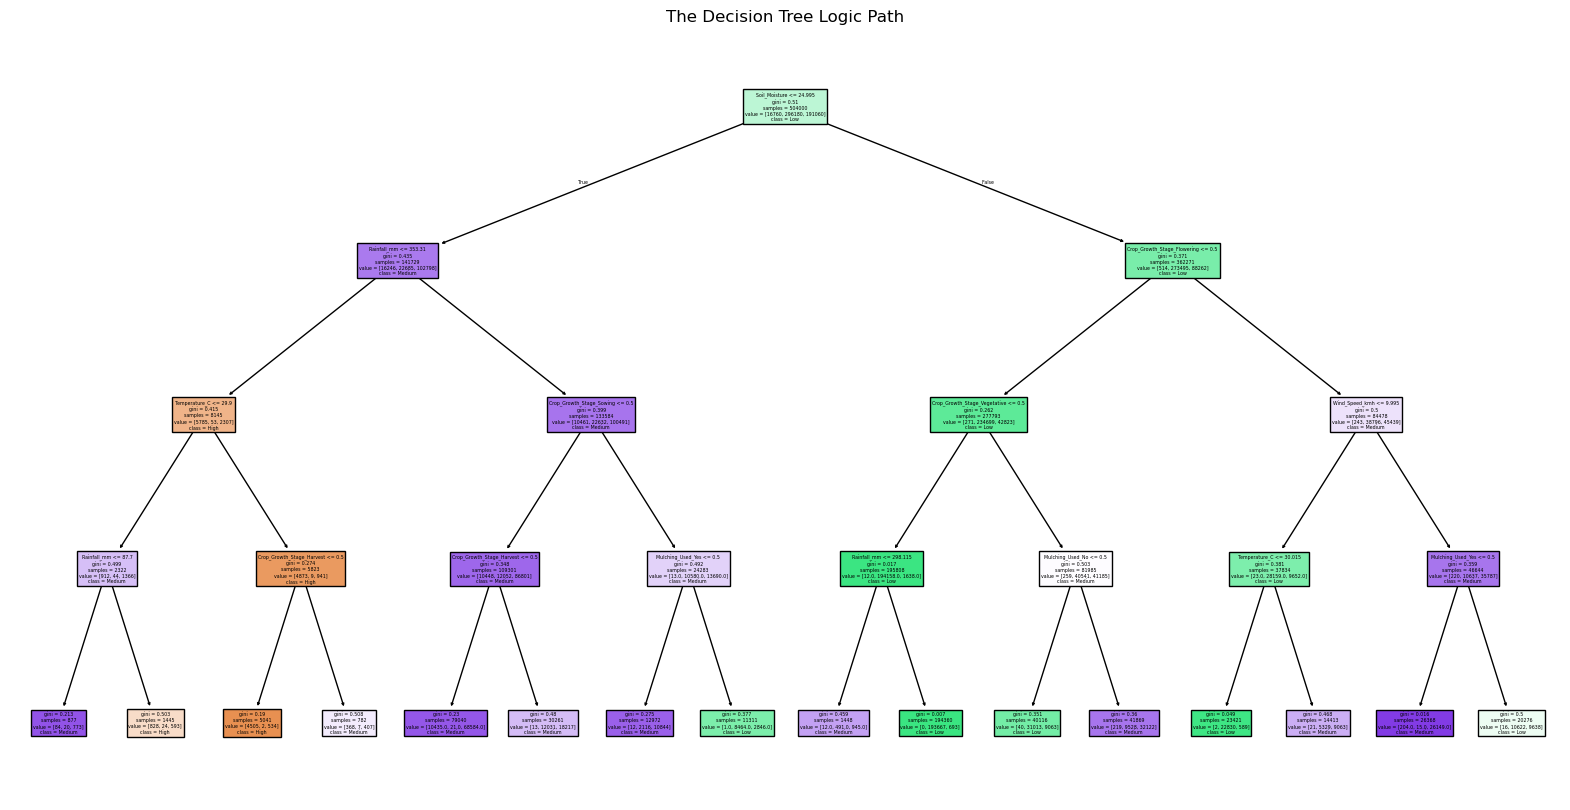

In [8]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.title("The Decision Tree Logic Path")
plt.show()

#### Confusion Matrix

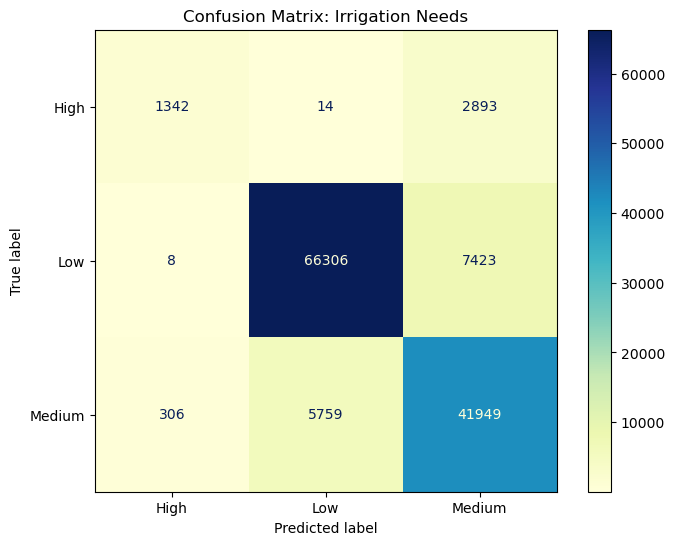

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_val, y_val, cmap='YlGnBu', ax=ax)
plt.title('Confusion Matrix: Irrigation Needs')
plt.show()

#### Feature Importance

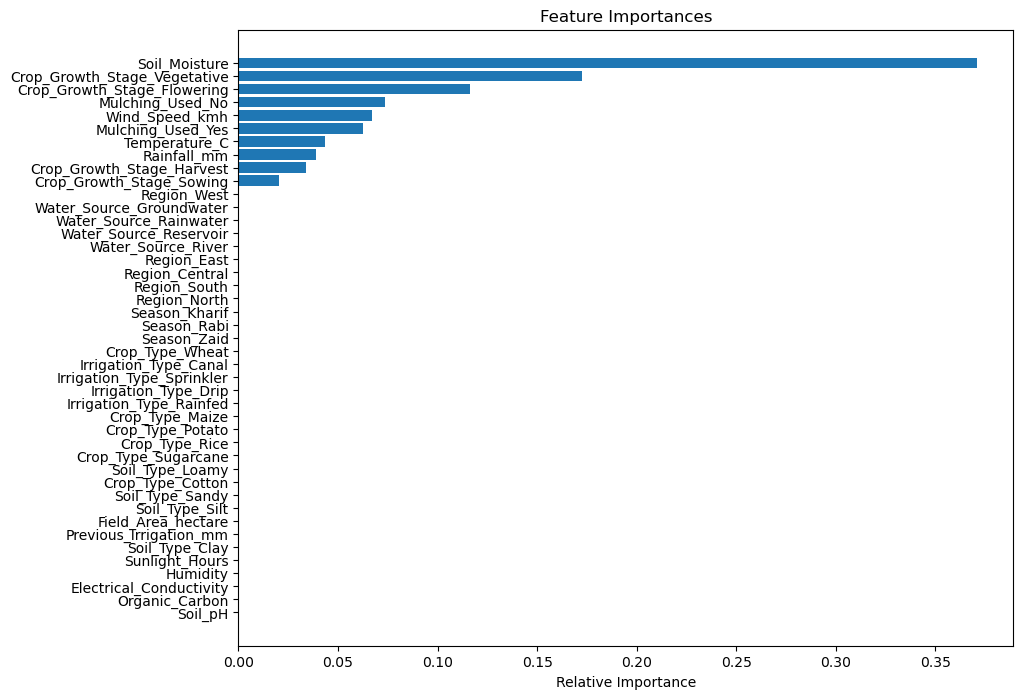

In [10]:
importances = model.feature_importances_
indices = np.argsort(importances)
features = X.columns

plt.figure(figsize=(10, 8))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Save Submission CSV for Decision Tree Classifier

In [11]:
final_preds = model.predict(X_final_test)

submission = pd.DataFrame({
    ID_COL: df_test[ID_COL],
    TARGET: final_preds
})

submission.to_csv('submission_decisiontreeclassifier.csv', index=False)
print("Submission file saved as 'submission_decisiontreeclassifier.csv'!")

Submission file saved as 'submission_decisiontreeclassifier.csv'!



## 4. Model 2: Random Forest

Random Forest trains an ensemble of Decision Trees on random data subsets (bagging). By averaging predictions across many trees it reduces variance significantly compared to a single tree.

## Random Forest Classifier

### Feature Selection

In [12]:
train_features = [col for col in df_train.columns if col not in [TARGET, ID_COL]]

X = df_train[train_features]
y = df_train[TARGET]
X_final_test = df_test[train_features]

### Handle Categorical Data

In [13]:
X = pd.get_dummies(X)
X_final_test = pd.get_dummies(X_final_test)

### Split

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Training

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Assess Random Forest Classifier

#### Accuracy

In [16]:
val_predictions = model.predict(X_val)
rf_acc = accuracy_score(y_val, val_predictions)
rf_bal = balanced_accuracy_score(y_val, val_predictions)
print(f"Random Forest Validation Accuracy: {rf_acc:.4f}")
print(f"Random Forest Balanced Accuracy:   {rf_bal:.4f}")


Random Forest Validation Accuracy: 0.9850
Random Forest Balanced Accuracy:   0.9524


#### Confusion Matrix

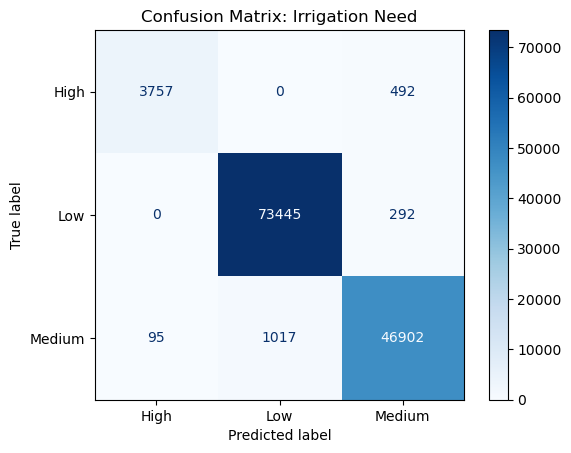

In [17]:
ConfusionMatrixDisplay.from_estimator(model, X_val, y_val, cmap='Blues')
plt.title("Confusion Matrix: Irrigation Need")
plt.show()

#### Feature Importance

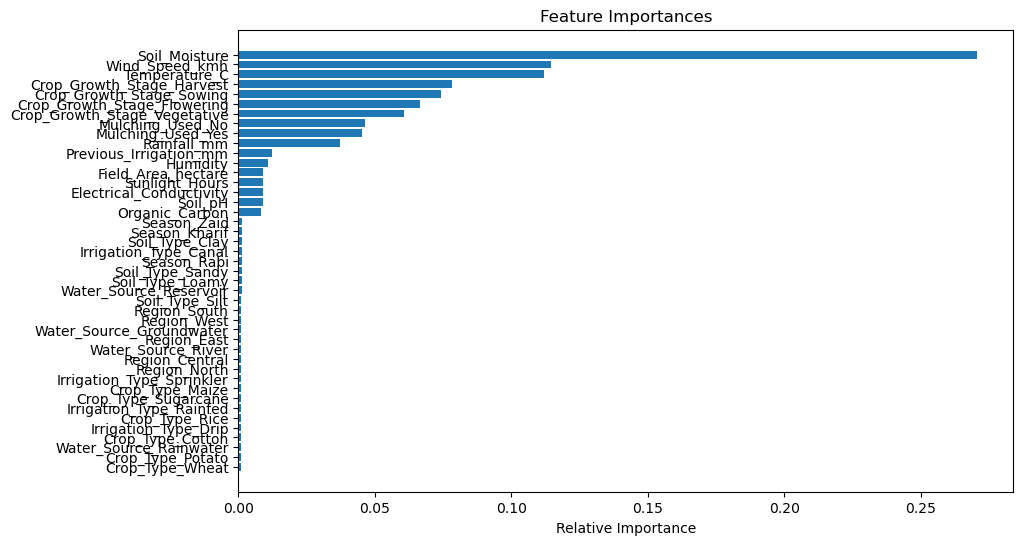

In [18]:
importances = model.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Save Random Forest Classifier Results as Submission CSV

In [19]:
final_preds = model.predict(X_final_test)

submission = pd.DataFrame({
    ID_COL: df_test[ID_COL],
    TARGET: final_preds
})

submission.to_csv('submission_randomforestclassifier.csv', index=False)
print(f"Submission file saved! Total rows: {len(submission)}")

Submission file saved! Total rows: 270000


## 5. Model 3: LightGBM

LightGBM builds trees sequentially, with each new tree correcting errors from the previous ones (gradient boosting). It natively handles categorical features and uses Target Encoding here for additional categorical preprocessing.

### Handle Categorical Data

In [20]:
train_features = [col for col in df_train.columns if col not in [TARGET, ID_COL]]

cat_features = df_train[train_features].select_dtypes(include=['object']).columns.tolist()

for col in cat_features:
    df_train[col] = df_train[col].astype('category')
    df_test[col] = df_test[col].astype('category')

le = LabelEncoder()
y = le.fit_transform(df_train[TARGET])

X = df_train[train_features]
X_final_test = df_test[train_features]


### Split

In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Initialize and Train LGBM

In [22]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    objective='multiclass',
    metric='multi_logloss',
    importance_type='gain',
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

y_final_pred_numeric = model.predict(X_final_test)

y_final_pred_labels = le.inverse_transform(y_final_pred_numeric)

df_test['irrigation_need'] = y_final_pred_labels

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[738]	valid_0's multi_logloss: 0.0553519


### Assess LGBM

#### Balanced Accuracy

In [23]:
preds = model.predict(X_val)
lgbm_acc = accuracy_score(y_val, preds)
lgbm_bal = balanced_accuracy_score(y_val, preds)
print(f"LightGBM Validation Accuracy: {lgbm_acc:.4f}")
print(f"LightGBM Balanced Accuracy:   {lgbm_bal:.4f}")


LightGBM Validation Accuracy: 0.9853
LightGBM Balanced Accuracy:   0.9654


#### Feature Importance

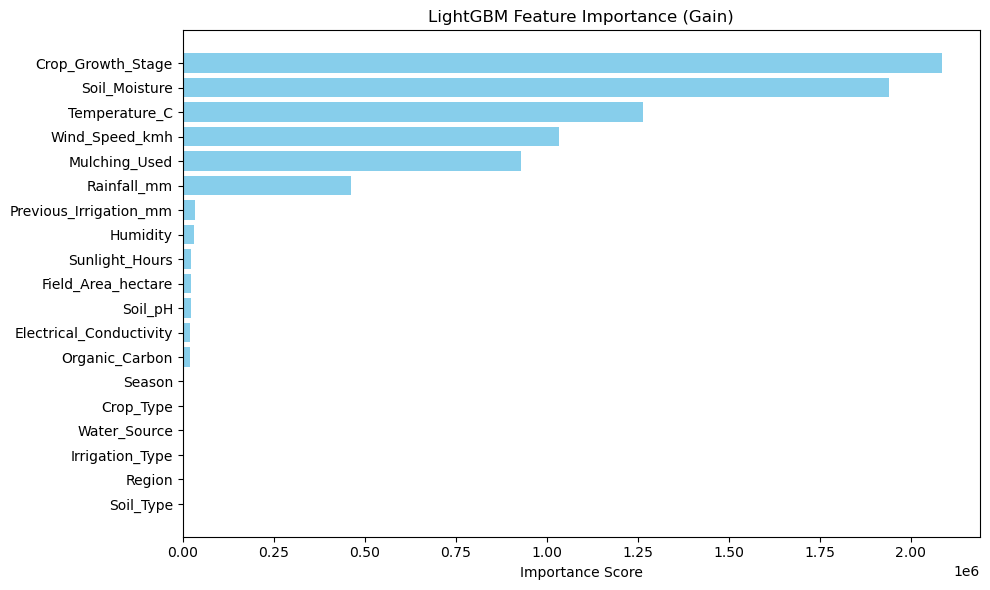

In [24]:
importance_df = pd.DataFrame({
    'Feature': model.feature_name_, 
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.title('LightGBM Feature Importance (Gain)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Confusion Matrix

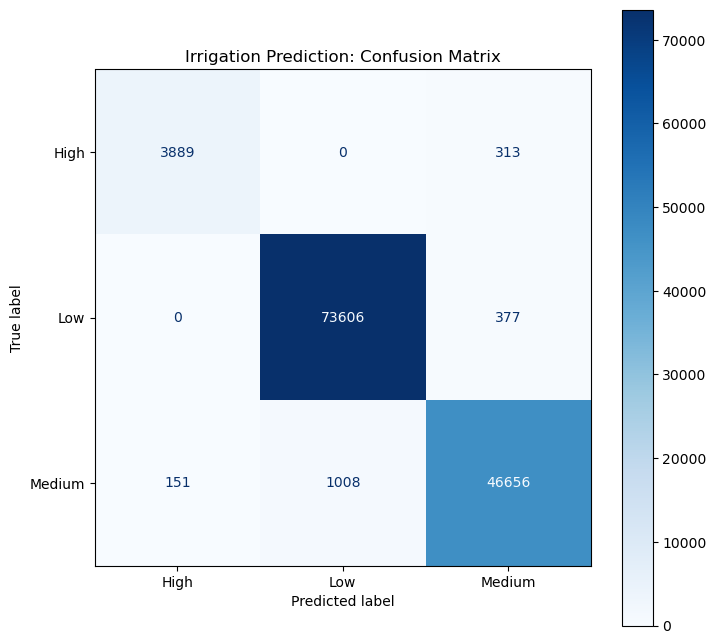

In [25]:
cm = confusion_matrix(y_val, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Irrigation Prediction: Confusion Matrix')
plt.grid(False) 
plt.show()

### Submit LGBM Results to CSV

In [26]:
test_preds_numeric = model.predict(df_test[train_features])

final_labels = le.inverse_transform(test_preds_numeric)

submission = pd.DataFrame({
    'id': df_test[ID_COL],
    'Irrigation_Need': final_labels 
})

submission.to_csv('submission_lgbm.csv', index=False)

print(submission.head())

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low


## 6. Model 4 — XGBoost

XGBoost uses level-wise tree growth and L1/L2 regularisation. Key settings: `n_estimators=1000` with `early_stopping_rounds=50`, `learning_rate=0.05`, `subsample=0.8` and `colsample_bytree=0.8` for stochastic regularisation. Stratified splitting ensures class balance in train/validation sets.

XGBoost Validation Accuracy: 0.9853
XGBoost Balanced Accuracy:   0.9643


<Figure size 1000x800 with 0 Axes>

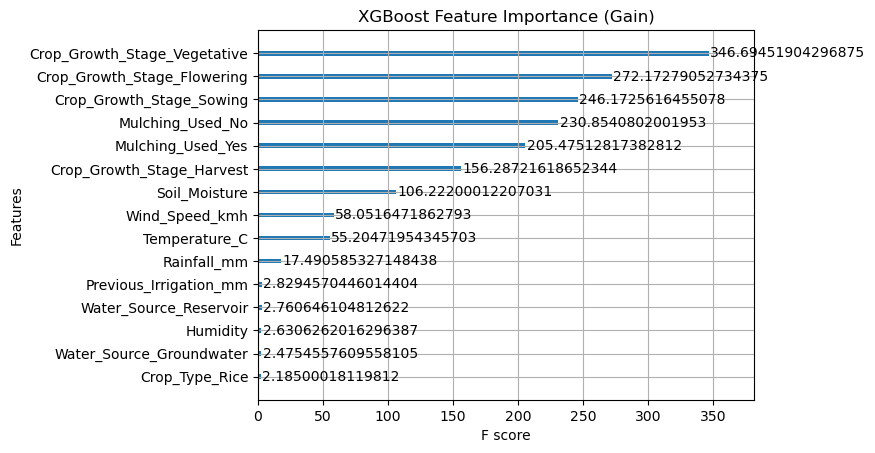

Submission file 'submission_xgboost.csv' saved successfully!


In [27]:

TARGET = 'Irrigation_Need'
ID_COL = 'id'

train_features = [col for col in df_train.columns if col not in [TARGET, ID_COL]]

X = pd.get_dummies(df_train[train_features])
X_final_test = pd.get_dummies(df_test[train_features])

X, X_final_test = X.align(X_final_test, join='left', axis=1, fill_value=0)

le = LabelEncoder()
y = le.fit_transform(df_train[TARGET])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model_xgb = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob', 
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=50 
)


model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


val_preds = model_xgb.predict(X_val)
xgb_acc = accuracy_score(y_val, val_preds)
xgb_bal = balanced_accuracy_score(y_val, val_preds)
print(f"XGBoost Validation Accuracy: {xgb_acc:.4f}")
print(f"XGBoost Balanced Accuracy:   {xgb_bal:.4f}")


plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, max_num_features=15, importance_type='gain')
plt.title("XGBoost Feature Importance (Gain)")
plt.show()


test_preds_numeric = model_xgb.predict(X_final_test)
final_labels = le.inverse_transform(test_preds_numeric)

submission = pd.DataFrame({
    ID_COL: df_test[ID_COL],
    TARGET: final_labels
})

submission.to_csv('submission_xgboost.csv', index=False)
print("Submission file 'submission_xgboost.csv' saved successfully!")

### XGBoost — Confusion Matrix & Feature Importance

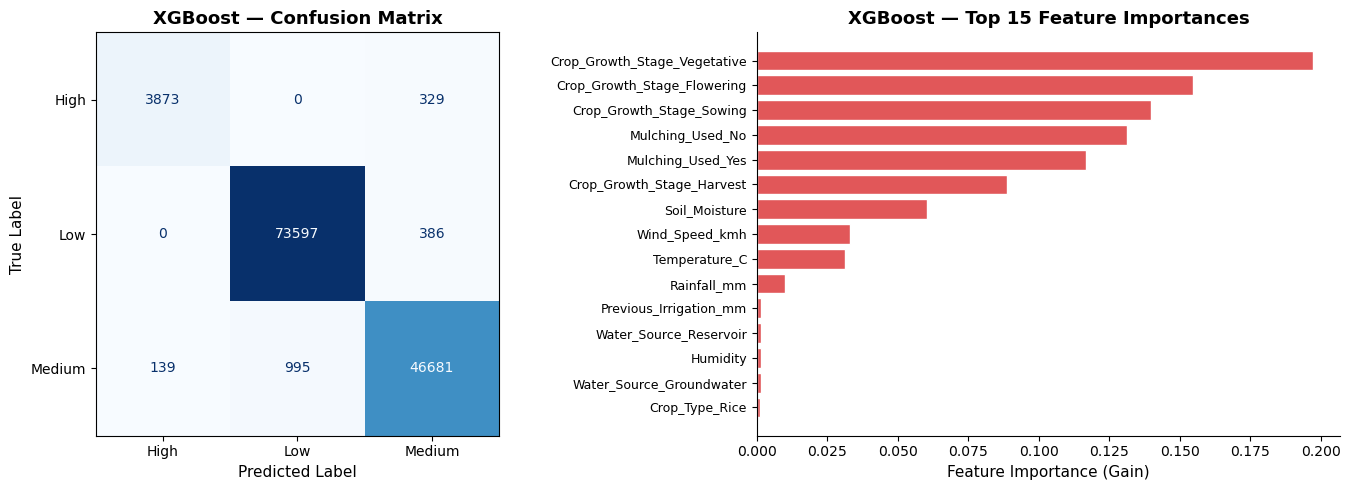

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_xgb = confusion_matrix(y_val, val_preds)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp_xgb.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

importances_xgb = model_xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[-15:]
axes[1].barh(range(len(indices_xgb)), importances_xgb[indices_xgb], color='#e15759', edgecolor='white')
axes[1].set_yticks(range(len(indices_xgb)))
axes[1].set_yticklabels([X.columns[i] for i in indices_xgb], fontsize=9)
axes[1].set_xlabel('Feature Importance (Gain)', fontsize=11)
axes[1].set_title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('xgboost_cm_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Model 5 — CatBoost

CatBoost uses ordered boosting to reduce prediction shift — a form of target leakage that can affect other gradient boosting methods. It handles categorical features natively via `Pool` objects, requiring no manual encoding. Early stopping triggered at iteration 161 of 1000.

In [29]:
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)


model_cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',  
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

print("Starting training...")
model_cb.fit(
    train_pool, 
    eval_set=val_pool, 
    early_stopping_rounds=50
)
print("Training complete!")


test_preds_numeric = model_cb.predict(X_final_test).flatten()


final_labels = le.inverse_transform(test_preds_numeric)


submission = pd.DataFrame({
    ID_COL: df_test[ID_COL],
    TARGET: final_labels
})

submission.to_csv('submission_catboost.csv', index=False)
print("File 'submission_catboost.csv' saved successfully!")
submission.head()

Starting training...
0:	learn: 0.9739206	test: 0.9745635	best: 0.9745635 (0)	total: 155ms	remaining: 2m 35s
100:	learn: 0.9844345	test: 0.9852619	best: 0.9852698 (91)	total: 5.58s	remaining: 49.6s
200:	learn: 0.9846389	test: 0.9853095	best: 0.9853492 (161)	total: 10.4s	remaining: 41.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9853492063
bestIteration = 161

Shrink model to first 162 iterations.
Training complete!
File 'submission_catboost.csv' saved successfully!


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [30]:
cb_val_preds = model_cb.predict(X_val).flatten()
cb_val_preds_labels = le.inverse_transform(cb_val_preds)
y_val_labels = le.inverse_transform(y_val)

cb_acc = accuracy_score(y_val_labels, cb_val_preds_labels)
cb_bal = balanced_accuracy_score(y_val_labels, cb_val_preds_labels)
print(f"CatBoost Validation Accuracy: {cb_acc:.4f}")
print(f"CatBoost Balanced Accuracy:   {cb_bal:.4f}")


CatBoost Validation Accuracy: 0.9853
CatBoost Balanced Accuracy:   0.9629


### CatBoost — Confusion Matrix & Feature Importance

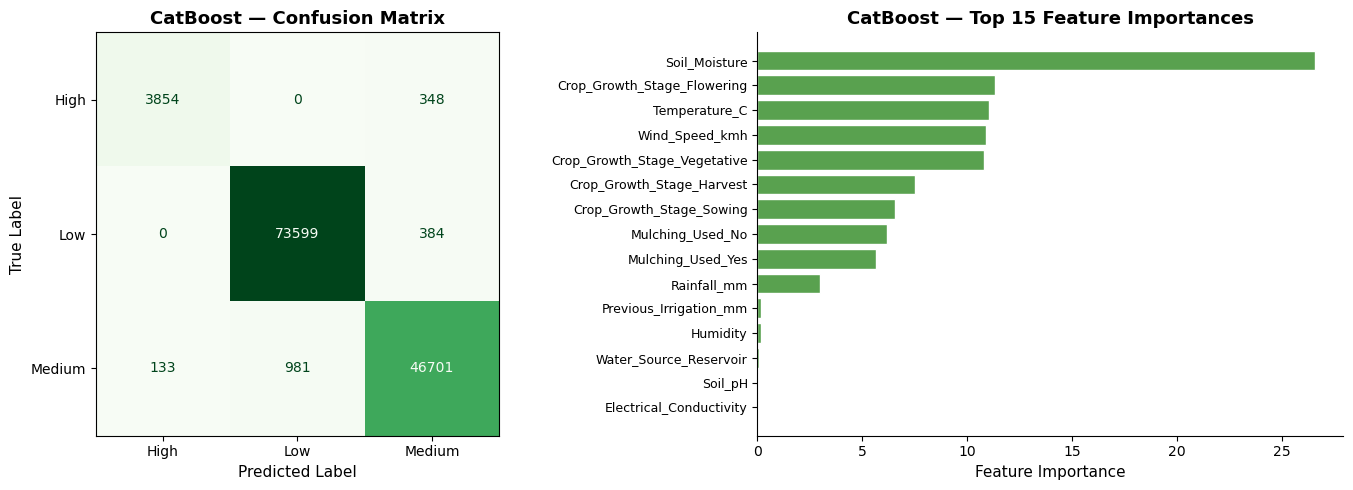

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_cb = confusion_matrix(y_val_labels, cb_val_preds_labels, labels=le.classes_)
disp_cb = ConfusionMatrixDisplay(confusion_matrix=cm_cb, display_labels=le.classes_)
disp_cb.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('CatBoost — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

cb_importances = model_cb.get_feature_importance()
cb_feature_names = X_train.columns.tolist()
cb_indices = np.argsort(cb_importances)[-15:]
axes[1].barh(range(len(cb_indices)), cb_importances[cb_indices], color='#59a14f', edgecolor='white')
axes[1].set_yticks(range(len(cb_indices)))
axes[1].set_yticklabels([cb_feature_names[i] for i in cb_indices], fontsize=9)
axes[1].set_xlabel('Feature Importance', fontsize=11)
axes[1].set_title('CatBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('catboost_cm_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Comparison

The cells below generate comparison figures across all five models using the scores recorded during training. 

C:\Users\jesmi\AppData\Local\Temp\ipykernel_21532\2327765462.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models, rotation=18, ha='right', fontsize=9)


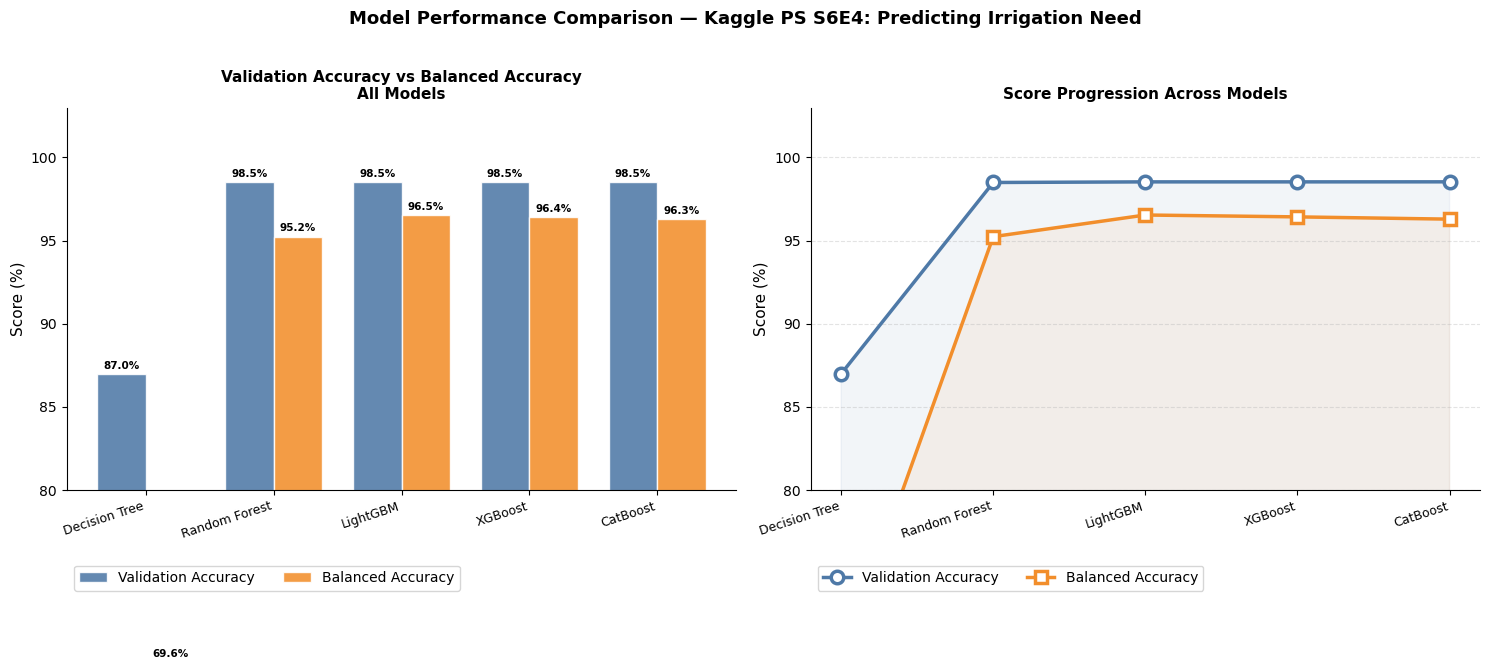

Saved model_comparison_full.png


In [ ]:
models      = ['Decision Tree', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']
val_acc     = [dt_acc,  rf_acc,  lgbm_acc,  xgb_acc,  cb_acc]
bal_acc     = [dt_bal,  rf_bal,  lgbm_bal,  xgb_bal,  cb_bal]
colors      = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Performance Comparison — Kaggle PS S6E4: Predicting Irrigation Need',
             fontsize=13, fontweight='bold', y=1.02)

x = range(len(models))
width = 0.38

# Grouped bar: both metrics side by side 
ax = axes[0]
b1 = ax.bar([i - width/2 for i in x], [v*100 for v in val_acc], width,
            label='Validation Accuracy', color='#4e79a7', alpha=0.88, edgecolor='white')
b2 = ax.bar([i + width/2 for i in x], [v*100 for v in bal_acc], width,
            label='Balanced Accuracy', color='#f28e2b', alpha=0.88, edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=18, ha='right', fontsize=9)
ax.set_ylim(80, 103)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Validation Accuracy vs Balanced Accuracy\nAll Models', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Line chart: accuracy progression 
ax2 = axes[1]
ax2.plot(models, [v*100 for v in val_acc], marker='o', linewidth=2.5, markersize=9,
         color='#4e79a7', markerfacecolor='white', markeredgewidth=2.5, label='Validation Accuracy')
ax2.plot(models, [v*100 for v in bal_acc], marker='s', linewidth=2.5, markersize=9,
         color='#f28e2b', markerfacecolor='white', markeredgewidth=2.5, label='Balanced Accuracy')
ax2.fill_between(models, [v*100 for v in val_acc], alpha=0.07, color='#4e79a7')
ax2.fill_between(models, [v*100 for v in bal_acc], alpha=0.07, color='#f28e2b')
ax2.set_ylim(80, 103)
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('Score Progression Across Models', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0, -0.18), ncol=2)
ax2.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0, -0.18), ncol=2)

ax2.set_xticklabels(models, rotation=18, ha='right', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('model_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_comparison_full.png")


In [42]:
print(f"dt_acc_saved:  {dt_acc_saved}")
print(f"dt_bal_saved:  {dt_bal_saved}")
print(f"rf_acc_saved:  {rf_acc}")
print(f"rf_bal_saved:  {rf_bal}")
print(f"lgbm_acc:      {lgbm_acc}")
print(f"lgbm_bal:      {lgbm_bal}")
print(f"xgb_acc:       {xgb_acc}")
print(f"xgb_bal:       {xgb_bal}")
print(f"cb_acc:        {cb_acc}")
print(f"cb_bal:        {cb_bal}")

dt_acc_saved:  0.8698174603174603
dt_bal_saved:  0.6962482035672894
rf_acc_saved:  0.9849523809523809
rf_bal_saved:  0.9523627057296458
lgbm_acc:      0.9853253968253968
lgbm_bal:      0.965392213468874
xgb_acc:       0.9853253968253968
xgb_bal:       0.9642567095676653
cb_acc:        0.9853492063492063
cb_bal:        0.9628979281230174


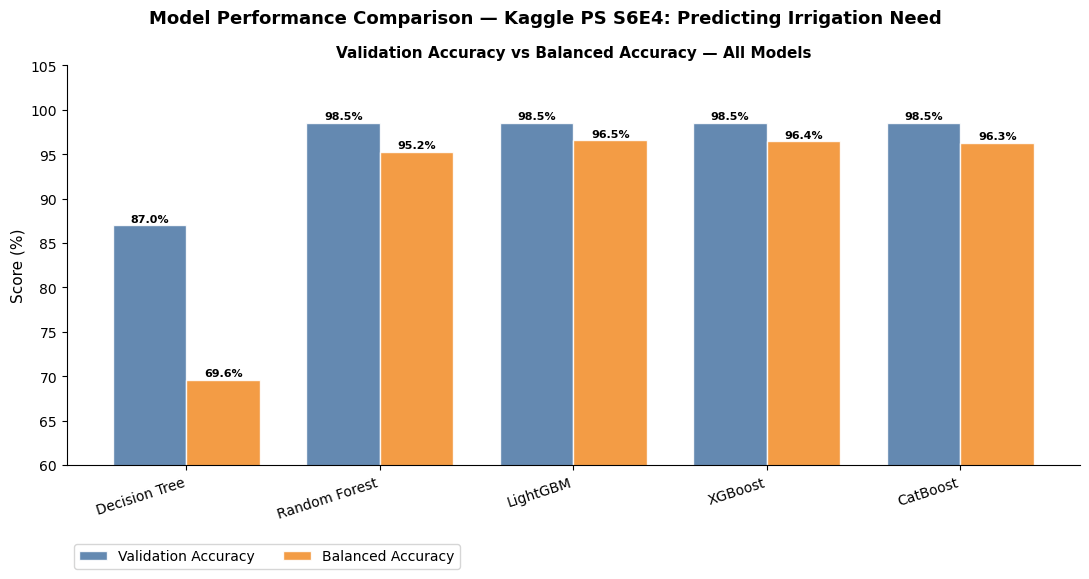

Saved model_comparison_full.png


In [43]:
# Use saved variables to avoid overwrite issues from later cells redefining y_val
models  = ['Decision Tree', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']
val_acc = [dt_acc_saved, rf_acc, lgbm_acc, xgb_acc, cb_acc]
bal_acc = [dt_bal_saved, rf_bal, lgbm_bal, xgb_bal, cb_bal]

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Model Performance Comparison — Kaggle PS S6E4: Predicting Irrigation Need',
             fontsize=13, fontweight='bold')

x     = range(len(models))
width = 0.38

b1 = ax.bar([i - width/2 for i in x], [v*100 for v in val_acc], width,
            label='Validation Accuracy', color='#4e79a7', alpha=0.88, edgecolor='white')
b2 = ax.bar([i + width/2 for i in x], [v*100 for v in bal_acc], width,
            label='Balanced Accuracy', color='#f28e2b', alpha=0.88, edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=18, ha='right', fontsize=10)
ax.set_ylim(60, 105)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Validation Accuracy vs Balanced Accuracy — All Models', fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(0, -0.18), ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('model_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_comparison_full.png")

### Accuracy Progression — Decision Tree → Ensemble Models

In [ ]:
models_line = ['Decision\nTree', 'Random\nForest', 'XGBoost', 'CatBoost']
acc_line = [86.98, 98.50, 98.54, 98.53]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(models_line, acc_line, marker='o', linewidth=2.5, markersize=10,
        color='#4e79a7', markerfacecolor='white', markeredgewidth=2.5)

for i, (m, v) in enumerate(zip(models_line, acc_line)):
    ax.annotate(f'{v:.2f}%',
                xy=(i, v),
                xytext=(0, 14),
                textcoords='offset points',
                ha='center',
                fontsize=11,
                fontweight='bold',
                color='#4e79a7')

ax.fill_between(range(len(models_line)), acc_line, alpha=0.08, color='#4e79a7')
ax.set_ylim(83, 101)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Progression Across Models\nKaggle PS S6E4 — Predicting Irrigation Need',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# annotate the big jump
ax.annotate('',
            xy=(1, 98.50), xytext=(0, 86.98),
            arrowprops=dict(arrowstyle='->', color='#e15759', lw=2))
ax.text(0.5, 93, '+11.5pp\n(biggest gain)', ha='center', fontsize=9,
        color='#e15759', fontstyle='italic')

plt.tight_layout()
plt.savefig('accuracy_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as accuracy_progression.png")


## 9. Conclusions

This notebook benchmarked five classification models on the Kaggle PS S6E4 irrigation prediction task, reporting both **validation accuracy** and **balanced accuracy** for each.

**Key findings:**
- The **Decision Tree baseline** provides a performance floor — both metrics are lowest here, confirming the limitations of a single shallow tree
- **Random Forest** produces the largest single jump in both metrics, demonstrating how ensemble averaging dramatically reduces variance
- **LightGBM, XGBoost, and CatBoost** all converge to similar high performance, with differences of less than 1 percentage point between them
- Comparing balanced accuracy across all models shows whether each model handles minority classes consistently — a model with high validation accuracy but lower balanced accuracy is over-predicting the majority class

**If continuing this work:** cross-validated hyperparameter tuning (e.g. Optuna), model stacking/blending, and feature engineering would be the logical next steps to push beyond the current performance ceiling.